# Univariate Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


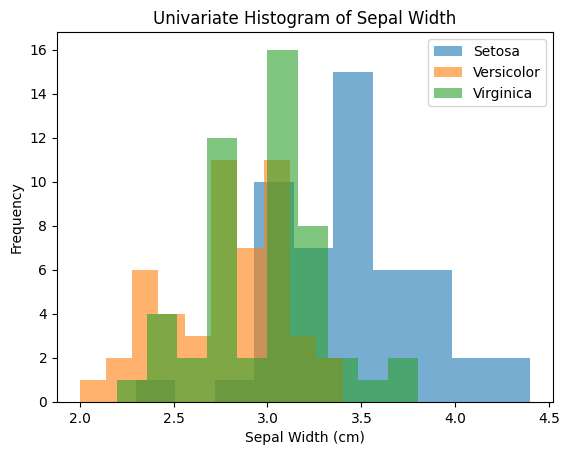

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
print(df.head())
df['species_name'] = df['species'].map({ 0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
setosa = df.loc[df['species_name'] == 'Setosa']
versicolor = df.loc[df['species_name'] == 'Versicolor']
virginica = df.loc[df['species_name'] == 'Virginica']
# Histogram plot
plt.hist(setosa['sepal width (cm)'], bins=10, alpha=0.6, label='Setosa')
plt.hist(versicolor['sepal width (cm)'], bins=10, alpha=0.6, label='Versicolor')
plt.hist(virginica['sepal width (cm)'], bins=10, alpha=0.6, label='Virginica')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.title('Univariate Histogram of Sepal Width')
plt.legend()
plt.show()

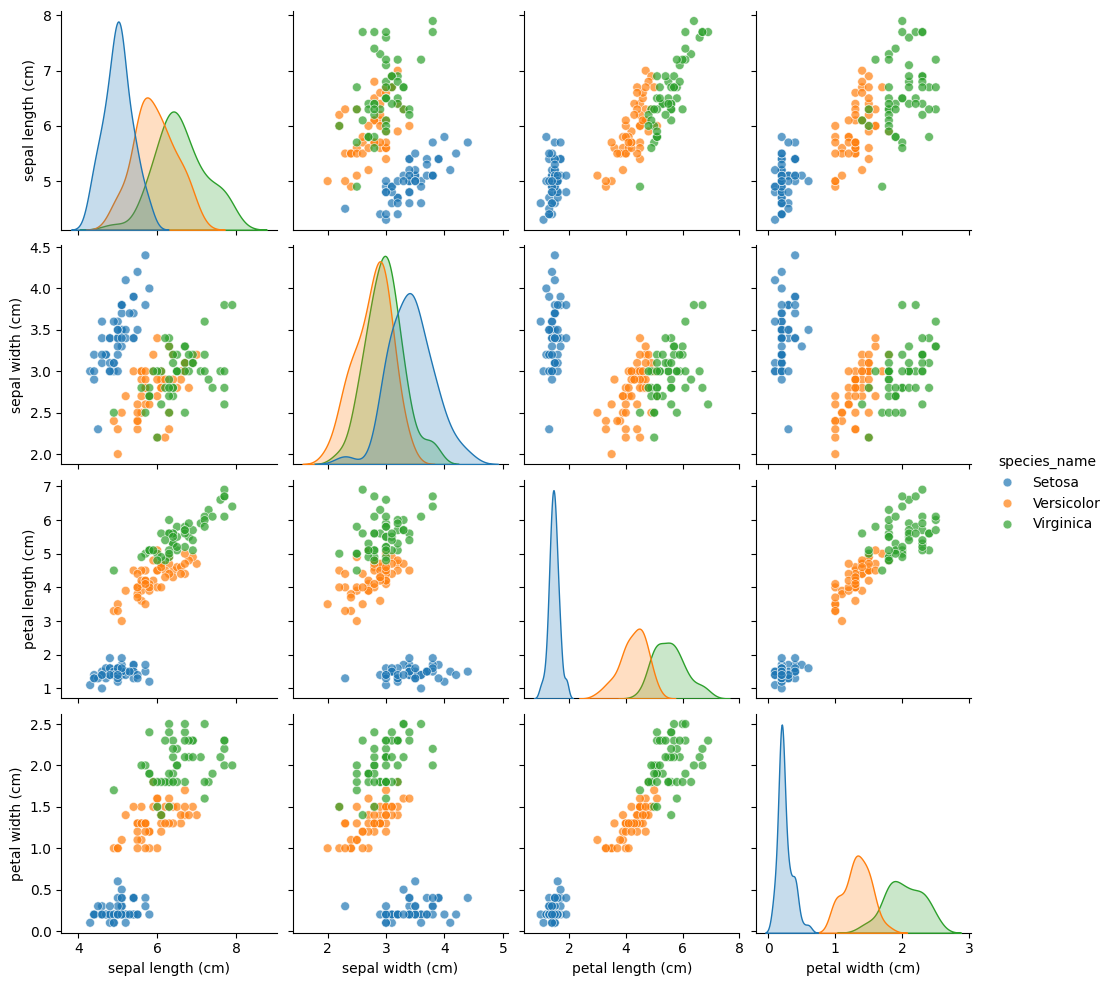

In [6]:
# Pairwise scatter plots
sns.pairplot(df, vars=iris.feature_names, hue='species_name', corner=False, plot_kws={'s':40, 'alpha':0.7})
plt.show()


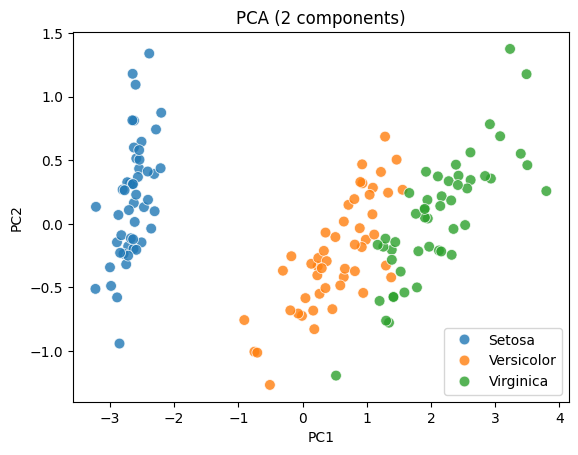

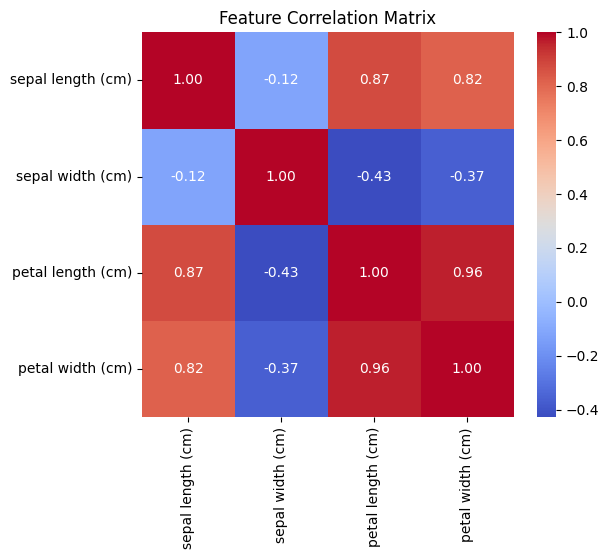

In [7]:
from sklearn.decomposition import PCA

# PCA 2-component scatter
X = df[iris.feature_names].values
pca = PCA(n_components=2, random_state=0)
pc = pca.fit_transform(X)
plt.figure()
sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=df['species_name'], s=60, alpha=0.8)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (2 components)')
plt.legend()
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()
